In [ ]:
import kagglehub

path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")
print("Path to dataset files:", path)

import os
print(os.listdir(path))

100%|██████████| 72.9M/72.9M [00:00<00:00, 77.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rohanrao/air-quality-data-in-india/versions/12
['city_day.csv', 'station_day.csv', 'station_hour.csv', 'city_hour.csv', 'stations.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(f"{path}/city_day.csv")
print(df.shape)
df.head()

(29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
print(df.info())
print("\n--- Missing values ---")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None

--- Missing values ---


In [ ]:
print(df.isnull().sum())

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [ ]:
print("\n--- AQI_Bucket distribution ---")


--- AQI_Bucket distribution ---


In [ ]:
print(df['AQI_Bucket'].value_counts())

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [ ]:
df_clean = df.dropna(subset=['AQI_Bucket']).copy()

In [ ]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

In [ ]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                   'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

for col in pollutant_cols:
    df_clean[col] = df_clean.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

df_clean[pollutant_cols] = df_clean[pollutant_cols].fillna(df_clean[pollutant_cols].median())

print(df_clean.isnull().sum())
print(df_clean.shape)

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
Year          0
Month         0
Day           0
DayOfWeek     0
dtype: int64
(24850, 20)


In [ ]:
from sklearn.preprocessing import LabelEncoder

features = pollutant_cols + ['Year', 'Month', 'Day', 'DayOfWeek']
X = df_clean[features]

le = LabelEncoder()
y = le.fit_transform(df_clean['AQI_Bucket'])

print("Classes:", list(le.classes_))
print(X.shape, y.shape)

Classes: ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']
(24850, 16) (24850,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(19880, 16) (4970, 16)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\n", classification_report(y_test, y_pred_dt, target_names=le.classes_))

Decision Tree Accuracy: 0.7812877263581489

               precision    recall  f1-score   support

        Good       0.71      0.59      0.65       268
    Moderate       0.79      0.83      0.81      1766
        Poor       0.67      0.60      0.64       556
Satisfactory       0.81      0.83      0.82      1645
      Severe       0.84      0.82      0.83       268
   Very Poor       0.78      0.72      0.75       467

    accuracy                           0.78      4970
   macro avg       0.77      0.73      0.75      4970
weighted avg       0.78      0.78      0.78      4970



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.8183098591549296

               precision    recall  f1-score   support

        Good       0.81      0.62      0.70       268
    Moderate       0.81      0.87      0.84      1766
        Poor       0.76      0.67      0.71       556
Satisfactory       0.84      0.85      0.85      1645
      Severe       0.88      0.79      0.83       268
   Very Poor       0.79      0.81      0.80       467

    accuracy                           0.82      4970
   macro avg       0.82      0.77      0.79      4970
weighted avg       0.82      0.82      0.82      4970



Decision Tree Accuracy : 0.7813
Random Forest Accuracy : 0.8183


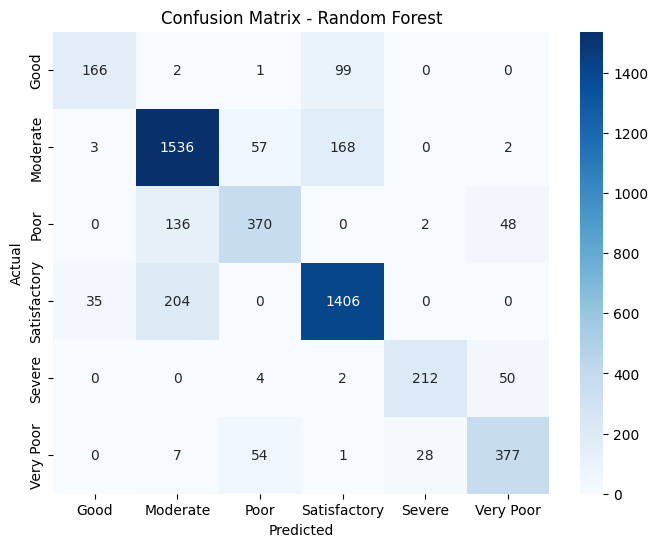

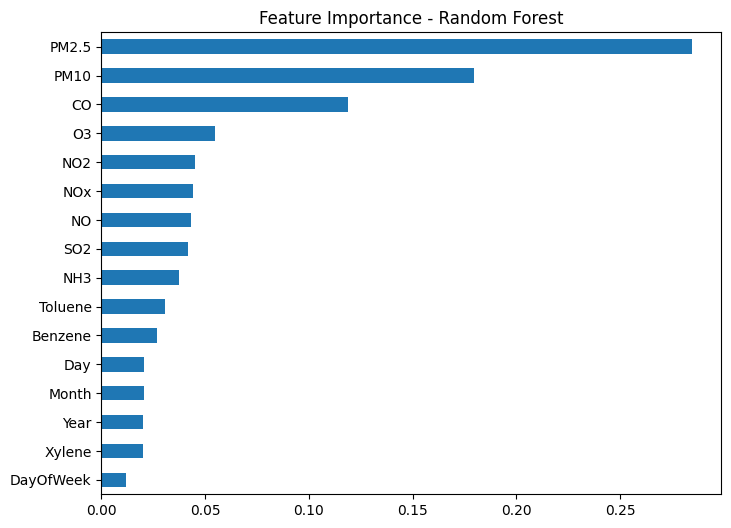

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Decision Tree Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import joblib

joblib.dump(dt_model, 'decision_tree_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("saved")

saved
